# Titanic survival prediction

In [1]:
#EDA and preprocessing and feature engineering
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Data acquisition

In [2]:
#load the training dataset and the test dataset
train_set = pd.read_csv("data/train.csv")
test_set = pd.read_csv("data/test.csv")

### Data discovering and preprocessing

In [3]:
print("shape of the training dataset :",train_set.shape)
print("list of features : ",train_set.columns.tolist())

shape of the training dataset : (891, 12)
list of features :  ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [4]:
#EDA
##Data structure inspection
print(train_set.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [5]:
print(train_set.tail())

     PassengerId  Survived  Pclass                                      Name  \
886          887         0       2                     Montvila, Rev. Juozas   
887          888         1       1              Graham, Miss. Margaret Edith   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
889          890         1       1                     Behr, Mr. Karl Howell   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch      Ticket   Fare Cabin Embarked  
886    male  27.0      0      0      211536  13.00   NaN        S  
887  female  19.0      0      0      112053  30.00   B42        S  
888  female   NaN      1      2  W./C. 6607  23.45   NaN        S  
889    male  26.0      0      0      111369  30.00  C148        C  
890    male  32.0      0      0      370376   7.75   NaN        Q  


In [6]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
train_set.Age.describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [8]:
train_set.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [9]:
print(train_set.duplicated().sum())
#there is no duplicates

0


In [10]:
print("Is every sample in the dataset is unique :",train_set.index.is_unique)

print(train_set.nunique())

Is every sample in the dataset is unique : True
PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64


In [11]:
missing = train_set.isnull().mean().sort_values(ascending = False)
print(missing)

Cabin          0.771044
Age            0.198653
Embarked       0.002245
PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
dtype: float64


In [12]:
missing = missing[missing > 0]
print(missing)

Cabin       0.771044
Age         0.198653
Embarked    0.002245
dtype: float64


In [13]:
# 77% of the passagers have a missing value for the feature Cabin, it looks very convenient to drop this feature.
train_set.drop(columns=['Cabin'], inplace=True)

# 19% of the passagers have a missing value for the feature Age. The percentage is quite high but we may think that it is an important feature
# We replace the missing values by the mean age
train_set["Age"] = train_set["Age"].fillna(train_set["Age"].median())

# Only 2% of passagers have a missing value in Embarked
train_set["Embarked"] = train_set["Embarked"].fillna(train_set["Embarked"].mode()[0])


In [14]:
missing = train_set.isnull().mean().sort_values(ascending = False)
missing = missing[missing > 0]
print(missing)


Series([], dtype: float64)


In [15]:
#Get rid of constant features
train_set = train_set.loc[ : , train_set.apply(pd.Series.nunique) != 1]

In [16]:
## Inspecting the type object features
print(train_set["Embarked"].unique())
print("-----------------------")
print(train_set["Embarked"].value_counts(dropna = False))

['S' 'C' 'Q']
-----------------------
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


### EDA

#### Univariate analysis : 


In [17]:
#Unvariate analysis

## We separate categorical and numerical features because univariate analysis is done differently for both of them
## Numerical columns
num_cols = ['Age','Fare']

## Categorical columns
cat_cols = ['Pclass','SibSp', 'Parch','Embarked','Sex']

## The other columns like PasengerId or Ticket are interesting to analyze

print('num_cols : ',num_cols)
print('cat_cols : ',cat_cols)

num_cols :  ['Age', 'Fare']
cat_cols :  ['Pclass', 'SibSp', 'Parch', 'Embarked', 'Sex']


count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64
Age skew :  0.5102446555756495
number of outliers :  66


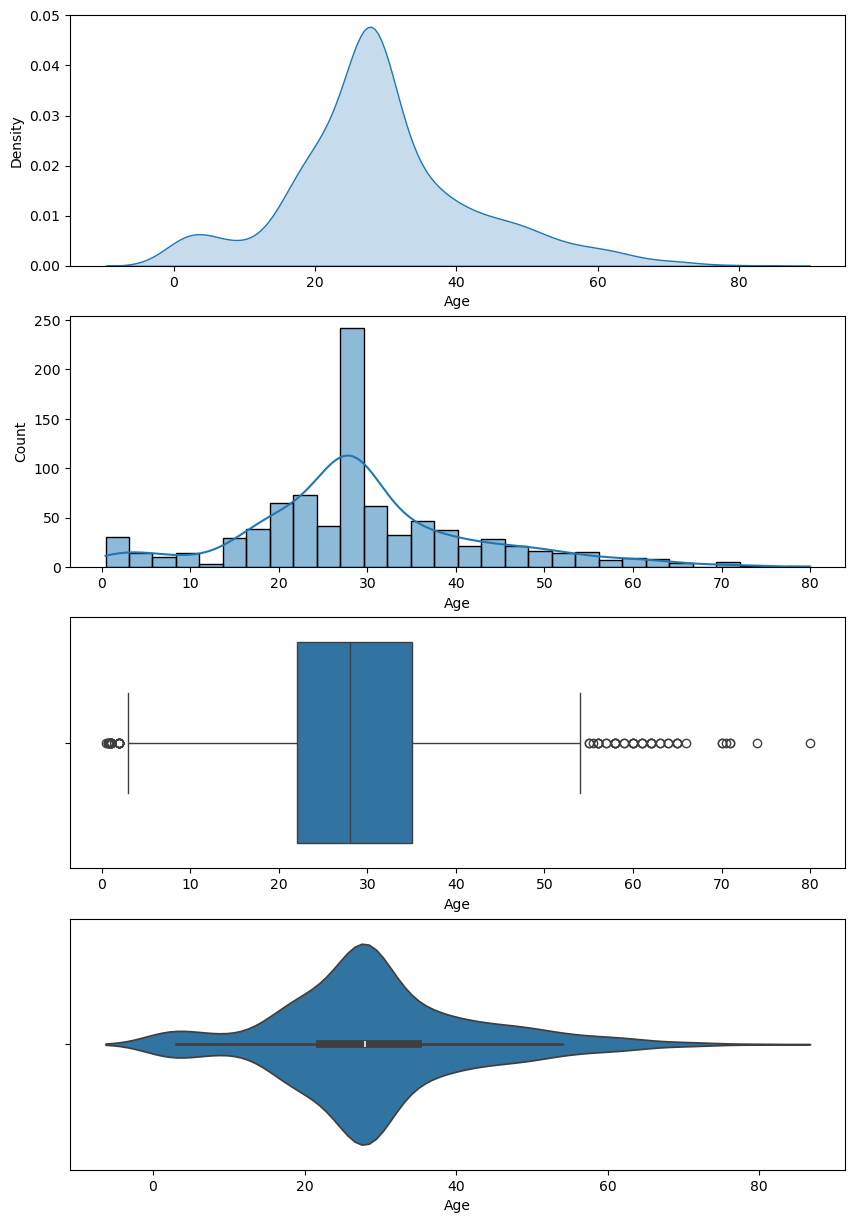

In [18]:
## Age
fig, axes = plt.subplots(4, 1, figsize=(10,15))
print(train_set["Age"].describe())
print("Age skew : ",train_set['Age'].skew())
sns.kdeplot(x=train_set['Age'], fill=True, ax=axes[0])
sns.histplot(x=train_set['Age'], fill=True, kde=True, ax=axes[1])
sns.boxplot(data=train_set, x="Age", ax=axes[2])
sns.violinplot(data=train_set, x="Age" , fill=True, ax=axes[3])

## Detecting outliers
q1 = train_set["Age"].quantile(0.25)
q3 = train_set["Age"].quantile(0.75)

iqr = q3 - q1

lower = q1 - iqr*1.5
upper = q3 + iqr*1.5
outliers = train_set[
    (train_set["Age"] < lower) |
    (train_set["Age"] > upper)
] 
print("number of outliers : ",len(outliers) )



#### Analysis of Age
##### 1. General analyzation 
The mean and the median are very close. Hence, we may concluds that the distribution of Age is quite symetric, something we can confirm by looking at the kde plot and the value of
of the skew. 
The boxplot is not very spread. Therefore the values of Age are quite concentrated around the median. There are many outliers, 66 in total, most of which lie above the upper whisker. However, the outlier values are not irrealistic. The maximum age is 80, which is a very plausible value. 
There is a relatively high number of young people on board, which explains the bump on the right of the kde graph.

##### 2. Missing values
As we have seen before, approximately 20% of Age values are missing. We will replace those values by the median value of this column. 
One can ask why the median and not the mean. The median is more suited because the distribution of Age is lightly skewed (driven by some outliers that are old people on board) 
to the right so the mean gives a slightly wrong impression about the Age.

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64
Fare skew :  4.787316519674893
Fare kurtosis :  33.39814088089868
number of outliers :  116


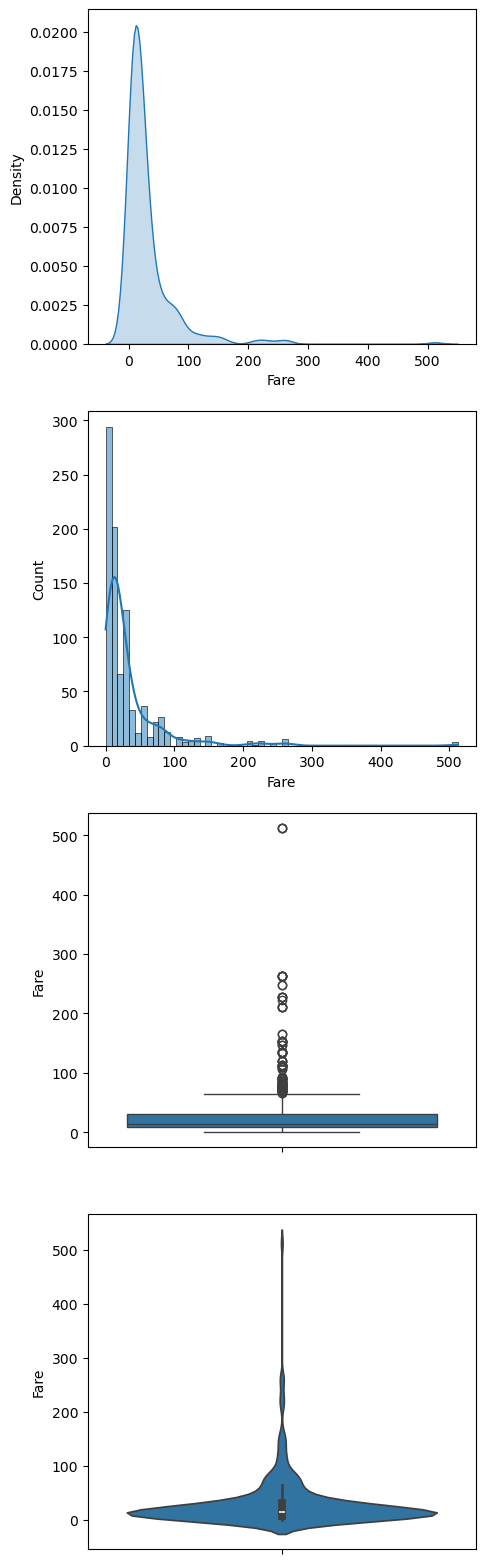

In [19]:
## Fare
fig, axes = plt.subplots(4,1, figsize=(5,20))
print(train_set["Fare"].describe())
print("Fare skew : ", train_set["Fare"].skew())
print("Fare kurtosis : ", train_set["Fare"].kurtosis())
sns.kdeplot(train_set['Fare'], fill=True, ax=axes[0])
sns.histplot(data=train_set, x="Fare", kde=True, ax=axes[1] )
sns.boxplot(train_set["Fare"], ax=axes[2])
sns.violinplot(train_set["Fare"],ax=axes[3])

## Detecting outliers
q1 = train_set["Fare"].quantile(0.25)
q3 = train_set["Fare"].quantile(0.75)

iqr = q3 - q1

lower = q1 - iqr*1.5
upper = q3 + iqr*1.5
outliers = train_set[
    (train_set["Fare"] < lower) |
    (train_set["Fare"] > upper)
] 
print("number of outliers : ",len(outliers))


#### Analysis of Fare
The median is very small compared to the mean. Hence the distribution is very right skewed, which can be confirmed by the value of the skew. We explain this by the fact that while most passengers in the ship paid low fares, the highest fares were huge that they moved the mean very far from the median. We can see this clearly by the huge difference that exists between the 75th quantile (31.00) and the maximum value (512.32).

<Axes: xlabel='SibSp', ylabel='Percent'>

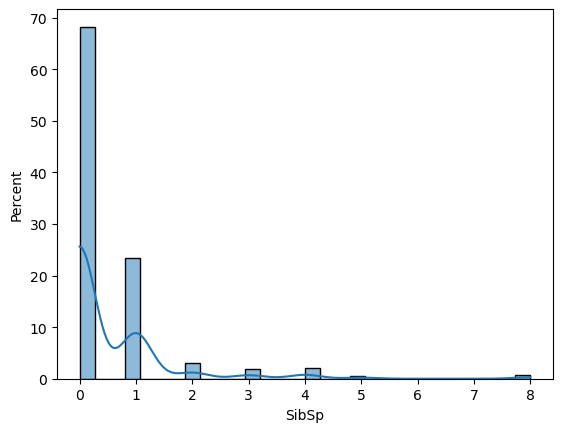

In [20]:
## SibSp
sns.histplot(train_set["SibSp"], kde=True, bins=30, stat="percent")
## Most people on the titanic were without spouses and siblings (approximately 68%)

<Axes: xlabel='Parch', ylabel='Percent'>

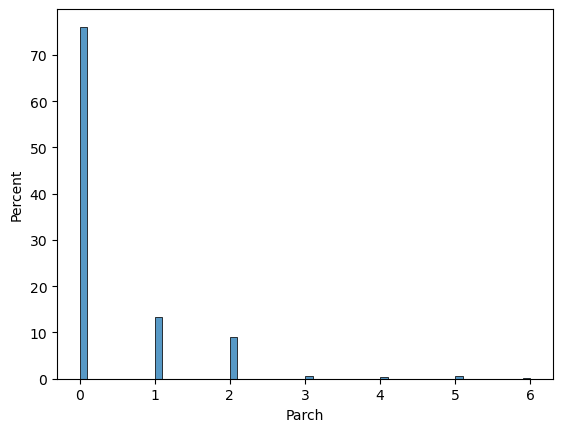

In [21]:
train_set['Parch'].value_counts()
sns.histplot(train_set["Parch"], stat="percent")
## Most people on the titanic were without chidren or parents

<Axes: xlabel='Sex', ylabel='Percent'>

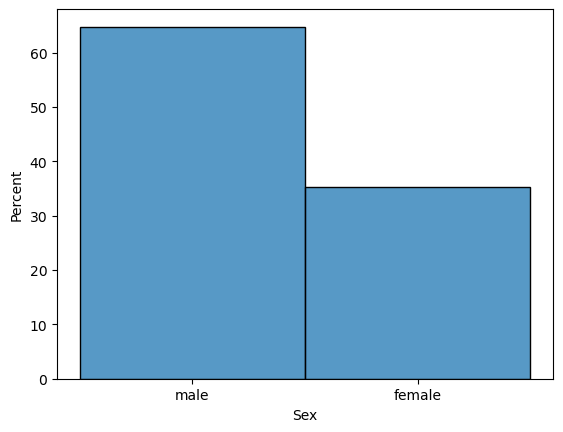

In [22]:
sns.histplot(train_set["Sex"], kde=False, bins=30, stat="percent")
## Most of the passengers were male (more then 60%). 

<Axes: xlabel='Embarked', ylabel='Percent'>

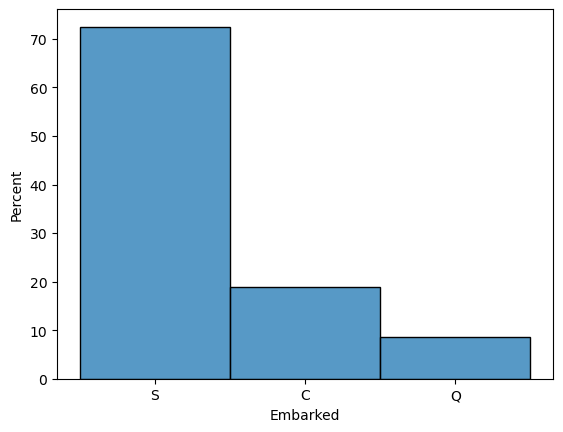

In [23]:
sns.histplot(train_set["Embarked"], kde=False, stat="percent")
## Embarked is a categorical feature indicating the port where a passenger boarded the ship.
## We observe that most passengers boarded in S. 

<Axes: xlabel='Survived', ylabel='Percent'>

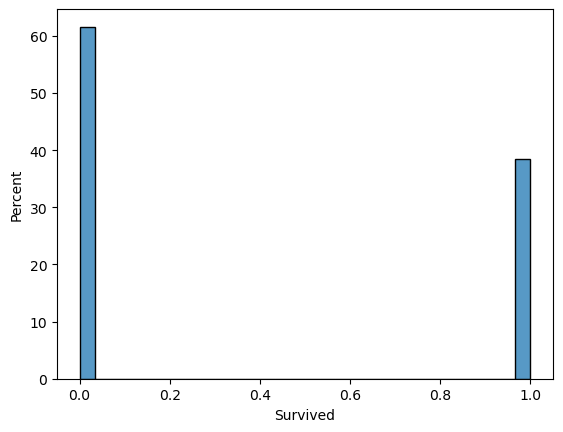

In [24]:
sns.histplot(train_set["Survived"], kde=False, bins=30, stat="percent")
## Survived is the target feature. We can see that the two classes are balanced (60% for balanced and 40% for balanced)

## Bivariate analysis

In [25]:
### Outlier detection using IQR
for col in num_cols :
    q1 = train_set[col].quantile(0.25)
    q3 = train_set[col].quantile(0.75)
    iqr = q3 - q1
    outliers = train_set[(train_set < q1 - 1.5*iqr) | (train_set > q3 - 1.5*iqr)]
    print(f'number of outliers for {col} is {len(outliers)}')
    

UFuncTypeError: ufunc 'greater' did not contain a loop with signature matching types (<class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.StrDType'>) -> None

In [ ]:
# Bivariate analysis
## Numerical features
for col in cat_cols :
    sns.boxplot(x=train_set['target'], y=train_set[col])
    plt.title(f"{col} vs target")
    plt.show()

In [ ]:
## Categorical features
for col in cat_cols :
    ct = pd.crosstab(train_set[col], train_set['S'], normalize='index')
    print(ct)
    ct.plot(kind='bar', stacked=True)
    plt.title(f'{col} vs target')
    plt.show()

KeyError: 'target'

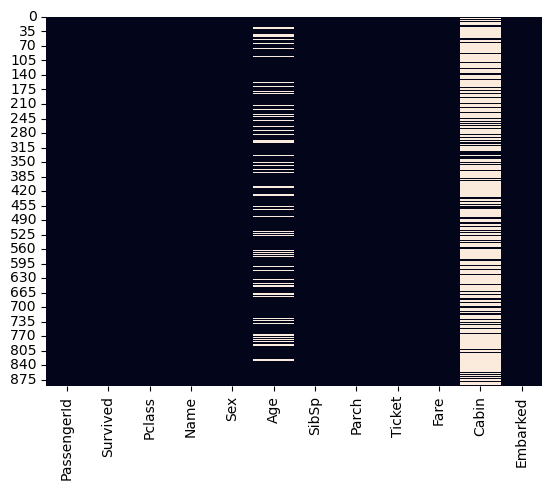

In [ ]:
sns.heatmap(train_set.isnull(), cbar=False)
plt.show()

In [ ]:
train_set.describe(percentiles=[0.01, 0.99]).T

,count,mean,std,min,1%,50%,99%,max
PassengerId,891.0,446.000000,257.353842,1.00,9.9,446.0000,882.10000,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0,0.0000,1.00000,1.0000
Pclass,891.0,2.308642,0.836071,1.00,1.0,3.0000,3.00000,3.0000
Age,714.0,29.699118,14.526497,0.42,1.0,28.0000,65.87000,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0,0.0000,5.00000,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0,0.0000,4.00000,6.0000
Fare,891.0,32.204208,49.693429,0.00,0.0,14.4542,249.00622,512.3292


In [ ]:
def iqr_outliers(series) :
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    print(q1 - 1.5*iqr)
    print(q3 + 1.5*iqr)
    print(q3)
    return series[(series < q1 -1.5*iqr) | (series > q3 + 1.5*iqr)]

outliers = iqr_outliers(train_set['Age'])
print(len(outliers)/train_set.shape[0])


-6.6875
64.8125
38.0
0.012345679012345678


<Axes: >

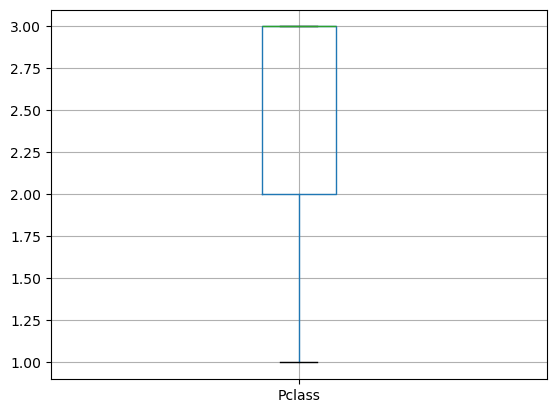

In [ ]:
train_set.boxplot(column='Pclass')

In [ ]:
train_set[['Pclass']].boxplot()

In [ ]:
#Preprocessing


In [ ]:
#Feature engineering

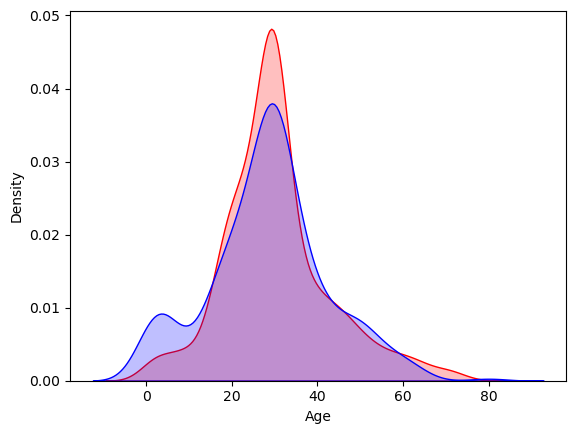

In [ ]:
plot = sns.kdeplot(train_set.loc[train_set["Survived"]==0].Age, color='red', fill=True)
plot = sns.kdeplot(train_set.Age[(train_set["Survived"]==1)], color='blue', fill=True)


In [ ]:
corr_matrix = train_set[num_cols].corr()
print(corr_matrix.index.tolist())
print(corr_matrix.columns.tolist())
# corr_matrix["Pclass"].sort_values(ascending=False).plot(kind='bar')
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
# corr_matrix["Pclass"].sort_values(ascending=False).plot(kind='bar')
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


<Axes: xlabel='Age'>

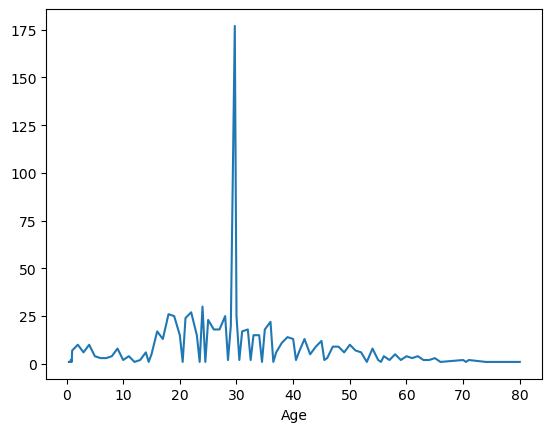

In [ ]:
train_set["Age"].value_counts().sort_index(ascending=True).plot()

In [ ]:
pd.crosstab(train_set[])

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3783860150.py, line 1)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform((X_train))
X_test_scaled = scaler.fit_transform(X_test)


### Modeling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metric import classification_report, roc_auc_score

#-------- separate features and target
X = train_set.drop(columns = ['Survived'])
y = train_set['Survived']

#-------- train/validation split
X_train, y_train, X_val, y_val = train_test_split(
    X, y,
    test_size = 0.2,
    stratify = y,
    random_state = 42 
)


model = Pipeline(steps = [
                        ("scaler", StandardScaler()), 
                        ("clf",LogisticRegression(
                            max_iter=1000,
                            class_weight="balanced",
                            random_state=42))
])


model.fit(X_train, y_train)

y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred))
print("ROC AUC :",roc_auc_score(y_val, y_proba))


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    m_enstimators=300,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=1
)

model.fit(X_train, y_train)
y_pred = model.predict(y_val)


In [ ]:
import optuna

def objective(trial) :
    params = {
        "n_estimators" : trial.suggest_int("n_estimators" : 100, 600),
        "max_depth" : trial.suggest_int("max_depth" : 3, 20),
        "min_samples_split" : trial.suggest_int("min_samples_split" : 2, 200),
        "min_samples_leaf" : trial.suggest_int("min_samples_leaf" : 2, 23),
        "max_features" : trial.suggest_categorical("max_features" : 2, 30),
        "random_state" : 42,
        "n_jobs" : -1
    }

    model = RandomForestClassifier(** params)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return score





In [ ]:
from sklearn.preprocessing import MinMaxScaler

df = pd.DataFrame(train_set, columns=['Age', 'Fare'])
scaler = MinMaxScaler()
scaled_value = scaler.fit_transform(df)
scaled_value.head()

NameError: name 'train_set' is not defined

In [ ]:
scaler = StandardScaler()

import statistics as st
import statistics as st


In [ ]:
# Funtion to detect outliers using the 

### Model evaluation

### Deployment